In [6]:
import pandas as pd

df = pd.read_csv('Highest-Holywood-Grossing-Movies.csv')
print(f"CSV Info: {df.describe()}")

if df['World Wide Sales (in $)'].dtype == 'object':
    df['sales_numberic'] = (
        df['World Wide Sales (in $)']
        .str.replace('$', '', regex=False)
        .str.replace(',', '', regex=False)
        .astype(float)
    )
else:
    df['sales_numberic'] = df['World Wide Sales (in $)']

print("---Statistical Summary of Sales---")
print(df['sales_numberic'].describe())

threshold = 500000000

high_sales_movies = df[df['sales_numberic'] > threshold]

result = high_sales_movies[['Title', 'World Wide Sales (in $)']].sort_values(by='Title')

print(f"\n---Movies with Sales > ${threshold}---")
print(result.head(10))
print(f"\nTotal movies found: {len(high_sales_movies)}")

CSV Info:         Unnamed: 0         Year  Domestic Sales (in $)  \
count  1000.000000  1000.000000           1.000000e+03   
mean    499.500000  2008.181000           1.646405e+08   
std     288.819436    10.585854           1.197541e+08   
min       0.000000  1937.000000           6.752000e+03   
25%     249.750000  2002.000000           9.572506e+07   
50%     499.500000  2010.000000           1.349169e+08   
75%     749.250000  2016.000000           1.983993e+08   
max     999.000000  2023.000000           9.366622e+08   

       International Sales (in $)  World Wide Sales (in $)  
count                1.000000e+03             1.000000e+03  
mean                 2.640890e+08             4.228430e+08  
std                  2.133847e+08             3.054844e+08  
min                  2.450000e+07             1.799689e+08  
25%                  1.321190e+08             2.272899e+08  
50%                  1.941077e+08             3.197148e+08  
75%                  3.188993e+08       

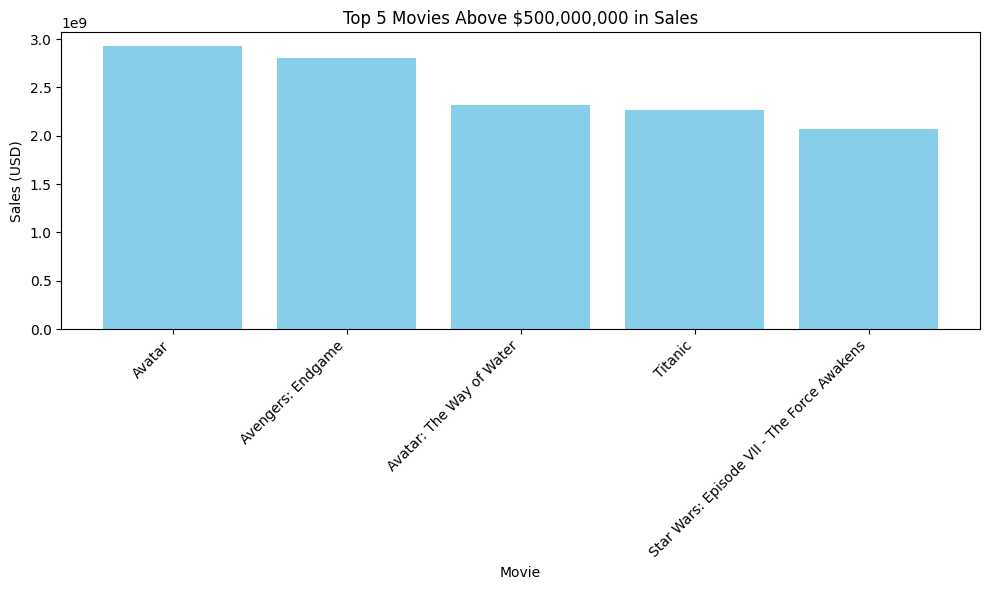

In [8]:
import matplotlib.pyplot as plt

top_5 = high_sales_movies.nlargest(5, 'sales_numberic')

plt.figure(figsize=(10, 6))
plt.bar(top_5['Title'], top_5['sales_numberic'], color='skyblue')
plt.title(f"Top 5 Movies Above ${threshold:,} in Sales")
plt.ylabel('Sales (USD)')
plt.xlabel('Movie')
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()